In [ ]:
# Mount Google Drive
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

drive.mount('/content/drive')

# Define project path in Drive
PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"
os.makedirs(PROJECT_PATH, exist_ok=True)

# Ensure subfolders exist
for sub in ["data/raw","data/processed","notebooks","results/eda_visualizations","results/output"]:
    os.makedirs(os.path.join(PROJECT_PATH, sub), exist_ok=True)

print("Project folder ready at:", PROJECT_PATH)

Mounted at /content/drive
Project folder ready at: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01


In [ ]:
# Dataset load
import pandas as pd
RAW_PATH = os.path.join(PROJECT_PATH, "data/raw/heart.csv")
df = pd.read_csv(RAW_PATH)
print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
# Preprocessing Technique 1- Feature Scaling_Normalization (IT24102753 Indrajith A.G.T.)

In [ ]:
# mapping old names to new names
column_name_mapping = {
    'age': 'age',
    'sex': 'sex',
    'cp': 'chest_pain_type',
    'trestbps': 'resting_bp',
    'chol': 'cholesterol',
    'fbs': 'fasting_blood_sugar',
    'restecg': 'resting_ecg',
    'thalach': 'max_heart_rate',
    'exang': 'exercise_angina',
    'oldpeak': 'st_depression',
    'slope': 'st_slope',
    'ca': 'num_major_vessels',
    'thal': 'thalassemia',
    'target': 'heart_disease'
}

df.rename(columns=column_name_mapping, inplace=True)

# Display the new column names and the first few rows to confirm
print("New Column Names:")
print(df.columns.tolist())
print("\nFirst 3 rows of the renamed dataset:")
print(df.head(3))

New Column Names:
['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate', 'exercise_angina', 'st_depression', 'st_slope', 'num_major_vessels', 'thalassemia', 'heart_disease']

First 3 rows of the renamed dataset:
   age  sex  chest_pain_type  resting_bp  cholesterol  fasting_blood_sugar  \
0   52    1                0         125          212                    0   
1   53    1                0         140          203                    1   
2   70    1                0         145          174                    0   

   resting_ecg  max_heart_rate  exercise_angina  st_depression  st_slope  \
0            1             168                0            1.0         2   
1            0             155                1            3.1         0   
2            1             125                1            2.6         0   

   num_major_vessels  thalassemia  heart_disease  
0                  2            3              0  
1   

age                    0
sex                    0
chest_pain_type        0
resting_bp             0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
st_depression          0
st_slope               0
num_major_vessels      0
thalassemia            0
heart_disease          0
dtype: int64


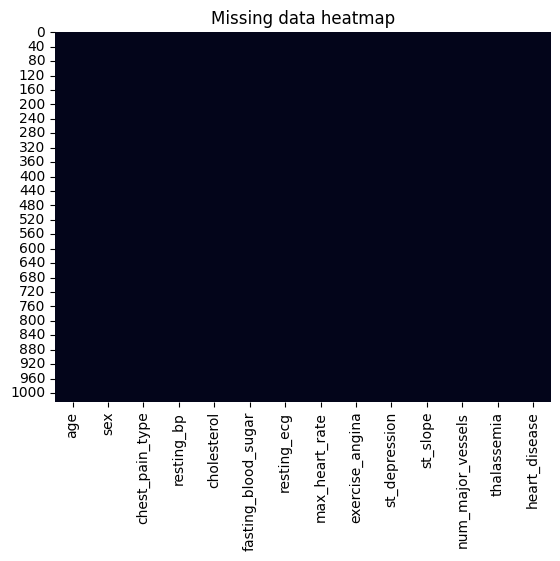

In [ ]:
# check missing values
print(df.isna().sum())
sns.heatmap(df.isnull(), cbar=False);
plt.title('Missing data heatmap');
plt.show()

In [ ]:
# Get comprehensive info
df.info()

# See specific data types
print("\nData Types:")
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1025 non-null   int64  
 1   sex                  1025 non-null   int64  
 2   chest_pain_type      1025 non-null   int64  
 3   resting_bp           1025 non-null   int64  
 4   cholesterol          1025 non-null   int64  
 5   fasting_blood_sugar  1025 non-null   int64  
 6   resting_ecg          1025 non-null   int64  
 7   max_heart_rate       1025 non-null   int64  
 8   exercise_angina      1025 non-null   int64  
 9   st_depression        1025 non-null   float64
 10  st_slope             1025 non-null   int64  
 11  num_major_vessels    1025 non-null   int64  
 12  thalassemia          1025 non-null   int64  
 13  heart_disease        1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Data Types:
age                      in

In [ ]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Select all numeric columns except target
numeric_features = df.select_dtypes(include=np.number).columns.tolist()
numeric_features.remove('heart_disease')

# Create copies of dataset
df_scaled_standard = df.copy()
df_scaled_minmax = df.copy()

# Apply StandardScaler
scaler_standard = StandardScaler()
df_scaled_standard[numeric_features] = scaler_standard.fit_transform(df[numeric_features])

# Apply MinMaxScaler (0 to 1)
scaler_minmax = MinMaxScaler()
df_scaled_minmax[numeric_features] = scaler_minmax.fit_transform(df[numeric_features])

# Display first 5 rows for comparison
print("Original Data (first 5 rows):")
print(df[numeric_features].head(), "\n")

print("Standard Scaled Data (first 5 rows):")
print(df_scaled_standard[numeric_features].head(), "\n")

print("MinMax Scaled Data (first 5 rows):")
print(df_scaled_minmax[numeric_features].head())

Original Data (first 5 rows):
   age  sex  chest_pain_type  resting_bp  cholesterol  fasting_blood_sugar  \
0   52    1                0         125          212                    0   
1   53    1                0         140          203                    1   
2   70    1                0         145          174                    0   
3   61    1                0         148          203                    0   
4   62    0                0         138          294                    1   

   resting_ecg  max_heart_rate  exercise_angina  st_depression  st_slope  \
0            1             168                0            1.0         2   
1            0             155                1            3.1         0   
2            1             125                1            2.6         0   
3            1             161                0            0.0         2   
4            1             106                0            1.9         1   

   num_major_vessels  thalassemia  
0       

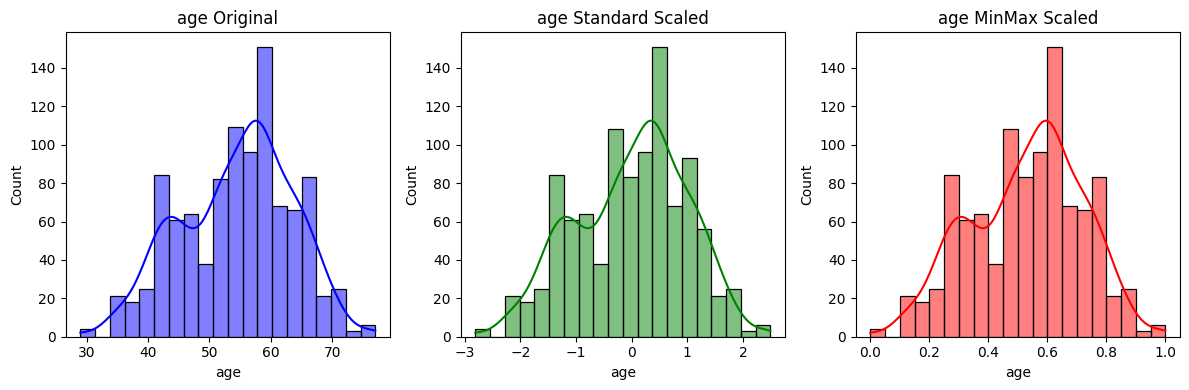

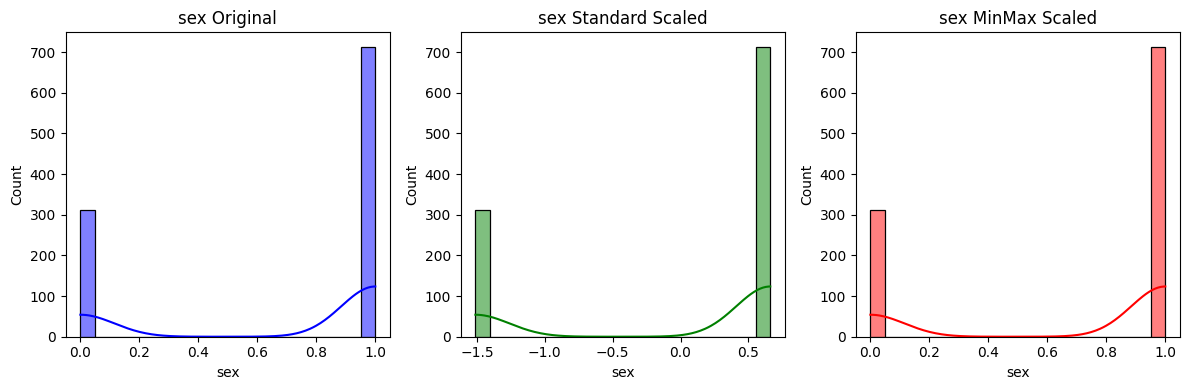

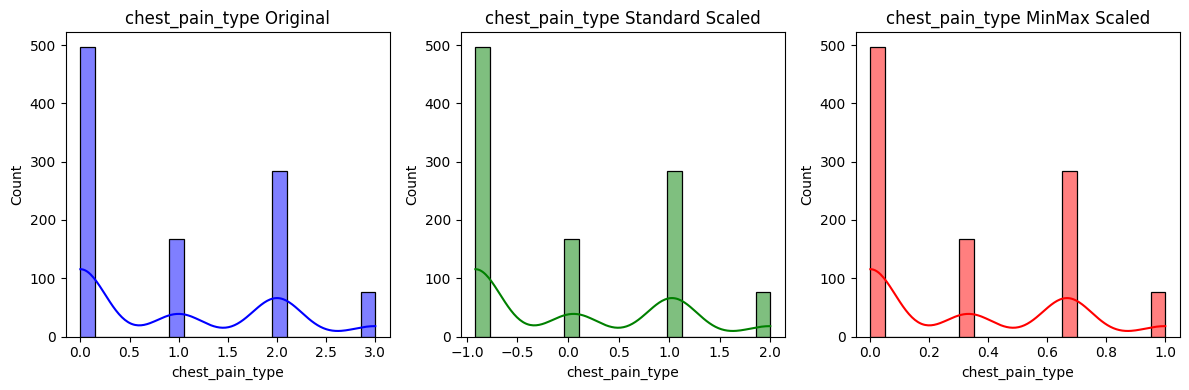

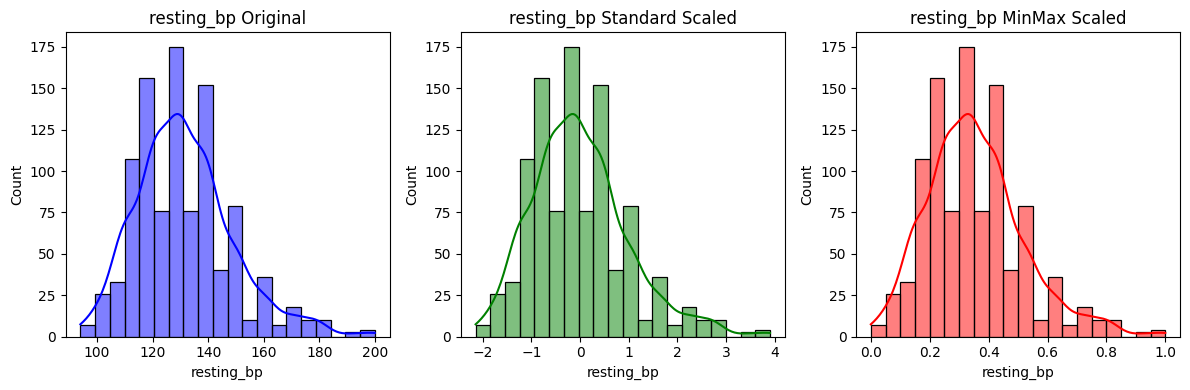

In [ ]:
# Visualization for multiple features

for col in numeric_features[:4]:  # show only first 5 to keep plots manageable
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    sns.histplot(df[col], bins=20, kde=True, color="blue")
    plt.title(f"{col} Original")

    plt.subplot(1,3,2)
    sns.histplot(df_scaled_standard[col], bins=20, kde=True, color="green")
    plt.title(f"{col} Standard Scaled")

    plt.subplot(1,3,3)
    sns.histplot(df_scaled_minmax[col], bins=20, kde=True, color="red")
    plt.title(f"{col} MinMax Scaled")

    plt.tight_layout()
    plt.show()

In [ ]:
# scaled dataset
df_final = df_scaled_standard.copy()

print("Final dataset ready for ML:", df_final.shape)
df_final.head()

Final dataset ready for ML: (1025, 14)


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,st_depression,st_slope,num_major_vessels,thalassemia,heart_disease
0,-0.268437,0.661504,-0.915755,-0.377636,-0.659332,-0.418878,0.891255,0.821321,-0.712287,-0.060888,0.995433,1.209221,1.089852,0
1,-0.158157,0.661504,-0.915755,0.479107,-0.833861,2.387330,-1.004049,0.255968,1.403928,1.727137,-2.243675,-0.731971,1.089852,0
2,1.716595,0.661504,-0.915755,0.764688,-1.396233,-0.418878,0.891255,-1.048692,1.403928,1.301417,-2.243675,-0.731971,1.089852,0
3,0.724079,0.661504,-0.915755,0.936037,-0.833861,-0.418878,0.891255,0.516900,-0.712287,-0.912329,0.995433,0.238625,1.089852,0
4,0.834359,-1.511706,-0.915755,0.364875,0.930822,2.387330,0.891255,-1.874977,-0.712287,0.705408,-0.624121,2.179817,-0.522122,0


In [ ]:
# Define save folder
PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"
SAVE_FOLDER = os.path.join(PROJECT_PATH, "results/eda_visualizations/feature_scaling")
os.makedirs(SAVE_FOLDER, exist_ok=True)

# Save plots
for col in numeric_features[:6]: #number of plots save
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    sns.histplot(df[col], bins=20, kde=True, color="blue")
    plt.title(f"{col} Original")

    plt.subplot(1,3,2)
    sns.histplot(df_scaled_standard[col], bins=20, kde=True, color="green")
    plt.title(f"{col} Standard Scaled")

    plt.subplot(1,3,3)
    sns.histplot(df_scaled_minmax[col], bins=20, kde=True, color="red")
    plt.title(f"{col} MinMax Scaled")

    plt.tight_layout()

    # Save each feature plot with its name
    plot_path = os.path.join(SAVE_FOLDER, f"{col}_scaling_comparison.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close()
    print("Plot saved to:", plot_path)

print("All scaling comparison plots saved successfully.")

Plot saved to: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/eda_visualizations/feature_scaling/age_scaling_comparison.png
Plot saved to: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/eda_visualizations/feature_scaling/sex_scaling_comparison.png
Plot saved to: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/eda_visualizations/feature_scaling/chest_pain_type_scaling_comparison.png
Plot saved to: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/eda_visualizations/feature_scaling/resting_bp_scaling_comparison.png
Plot saved to: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/eda_visualizations/feature_scaling/cholesterol_scaling_comparison.png
Plot saved to: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/eda_visualizations/feature_scaling/fasting_blood_sugar_scaling_comparison.png
All scaling comparison plots saved successfully.


In [ ]:
# Updates .csv file save
df_final_1 = df_scaled_standard.copy()

print("Final dataset ready for ML:", df_final_1.shape)

# Save processed dataset
PROC_PATH = os.path.join(PROJECT_PATH, "data/processed/IT24102753_scaled(1st).csv")
df_final_1.to_csv(PROC_PATH, index=False)
print("Saved scaled dataset to:", PROC_PATH)

Final dataset ready for ML: (1025, 14)
Saved scaled dataset to: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/data/processed/IT24102753_scaled(1st).csv


In [ ]:
# Preprocessing Technique 2- Feature Selection (IT24102739 Kumarasinghe H.K.M.E.S.)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from google.colab import drive

drive.mount('/content/drive')

PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"
RAW_PATH = f"{PROJECT_PATH}/data/processed/IT24102753_scaled(1st).csv"

# Load dataset
df = pd.read_csv(RAW_PATH)
print("Dataset loaded:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded: (1025, 14)


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,st_depression,st_slope,num_major_vessels,thalassemia,heart_disease
0,-0.268437,0.661504,-0.915755,-0.377636,-0.659332,-0.418878,0.891255,0.821321,-0.712287,-0.060888,0.995433,1.209221,1.089852,0
1,-0.158157,0.661504,-0.915755,0.479107,-0.833861,2.387330,-1.004049,0.255968,1.403928,1.727137,-2.243675,-0.731971,1.089852,0
2,1.716595,0.661504,-0.915755,0.764688,-1.396233,-0.418878,0.891255,-1.048692,1.403928,1.301417,-2.243675,-0.731971,1.089852,0
3,0.724079,0.661504,-0.915755,0.936037,-0.833861,-0.418878,0.891255,0.516900,-0.712287,-0.912329,0.995433,0.238625,1.089852,0
4,0.834359,-1.511706,-0.915755,0.364875,0.930822,2.387330,0.891255,-1.874977,-0.712287,0.705408,-0.624121,2.179817,-0.522122,0


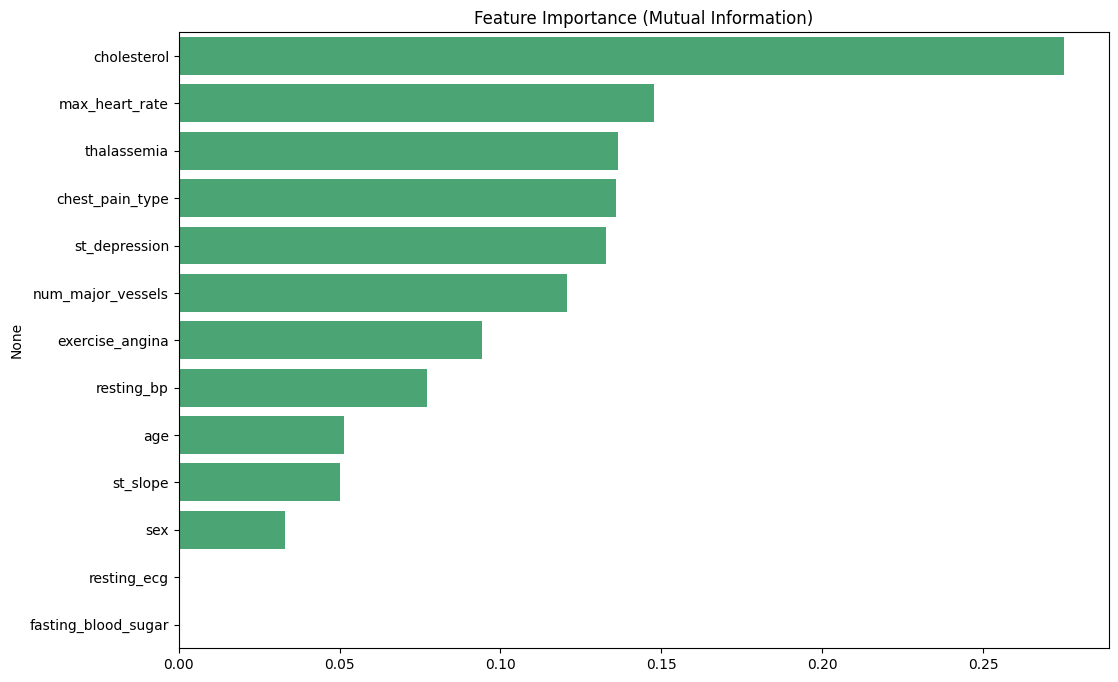

Top features:
 cholesterol            0.275314
max_heart_rate         0.147683
thalassemia            0.136632
chest_pain_type        0.135838
st_depression          0.132645
num_major_vessels      0.120577
exercise_angina        0.094175
resting_bp             0.077058
age                    0.051214
st_slope               0.050117
sex                    0.032968
resting_ecg            0.000515
fasting_blood_sugar    0.000000
dtype: float64


In [ ]:
# Feature Selection with Mutual Information

from sklearn.feature_selection import mutual_info_classif

# Drop rows with missing values for feature selection
X_clean = df.drop(columns=['heart_disease']).dropna()
y_clean = df.loc[X_clean.index, 'heart_disease']

# Mutual Information scores
mi = mutual_info_classif(X_clean, y_clean, discrete_features='auto', random_state=42)
mi_series = pd.Series(mi, index=X_clean.columns).sort_values(ascending=False)

# Plot Feature Importance
plt.figure(figsize=(12,8))
sns.barplot(x=mi_series.values, y=mi_series.index, color="mediumseagreen")
plt.title("Feature Importance (Mutual Information)")
plt.show()

print("Top features:\n", mi_series.head(16))

# Select Best Features
top_features = mi_series.head(16).index.tolist()   # pick best 16 features
df_selected = df[top_features + ['heart_disease']]       # keep selected + target

In [ ]:
# Define save folder
PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"
SAVE_FOLDER = os.path.join(PROJECT_PATH, "results/eda_visualizations/feature_selection")
os.makedirs(SAVE_FOLDER, exist_ok=True)

# Plot and save Mutual Information bar chart
plt.figure(figsize=(8,4))
sns.barplot(x=mi_series.values, y=mi_series.index, color="mediumseagreen")
plt.title("Feature Importance (Mutual Information)")
plt.tight_layout()

plot_path = os.path.join(SAVE_FOLDER, "mutual_information.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.close()
print("Plot saved to:", plot_path)

Plot saved to: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/eda_visualizations/feature_selection/mutual_information.png


In [ ]:
# Updates .csv file save
df_final_2 = df_selected.copy()
print("Final dataset ready for ML:", df_final_2.shape)

PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"
PROC_PATH = os.path.join(PROJECT_PATH, "data/processed/IT24102739_selected_features(2nd).csv")
os.makedirs(os.path.dirname(PROC_PATH), exist_ok=True)
df_final_2.to_csv(PROC_PATH, index=False)

print("Saved selected features dataset to:", PROC_PATH)

Final dataset ready for ML: (1025, 14)
Saved selected features dataset to: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/data/processed/IT24102739_selected_features(2nd).csv


In [ ]:
# Preprocessing Technique 3- Feature Engineering (IT24102748 Wijerathna K.M.S.R.)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from google.colab import drive

drive.mount('/content/drive')

PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"
RAW_PATH = f"{PROJECT_PATH}/data/processed/IT24102739_selected_features(2nd).csv"

# Load dataset
df = pd.read_csv(RAW_PATH)
print("Dataset loaded:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded: (1025, 14)


,cholesterol,max_heart_rate,thalassemia,chest_pain_type,st_depression,num_major_vessels,exercise_angina,resting_bp,age,st_slope,sex,resting_ecg,fasting_blood_sugar,heart_disease
0,-0.659332,0.821321,1.089852,-0.915755,-0.060888,1.209221,-0.712287,-0.377636,-0.268437,0.995433,0.661504,0.891255,-0.418878,0
1,-0.833861,0.255968,1.089852,-0.915755,1.727137,-0.731971,1.403928,0.479107,-0.158157,-2.243675,0.661504,-1.004049,2.387330,0
2,-1.396233,-1.048692,1.089852,-0.915755,1.301417,-0.731971,1.403928,0.764688,1.716595,-2.243675,0.661504,0.891255,-0.418878,0
3,-0.833861,0.516900,1.089852,-0.915755,-0.912329,0.238625,-0.712287,0.936037,0.724079,0.995433,0.661504,0.891255,-0.418878,0
4,0.930822,-1.874977,-0.522122,-0.915755,0.705408,2.179817,-0.712287,0.364875,0.834359,-0.624121,-1.511706,0.891255,2.387330,0


Explained variance ratio: [0.21369912 0.11971959]


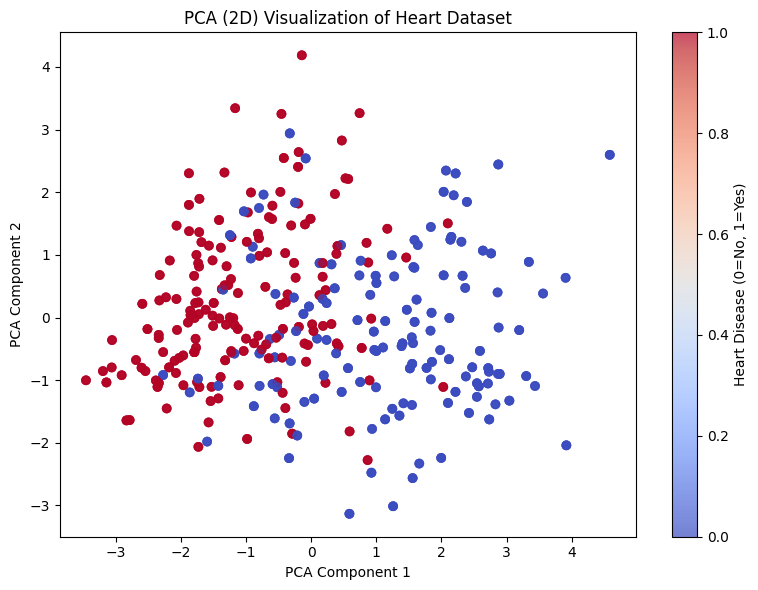

In [ ]:
# Dimensionality Reduction (PCA 2 Components)
# Numeric features only (exclude target)
X = df.drop(columns=['heart_disease'])
y = df['heart_disease']

# Standardize features for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

# Plot PCA 2D
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.7)
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_title("PCA (2D) Visualization of Heart Dataset")
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Heart Disease (0=No, 1=Yes)")
fig.tight_layout()
plt.show()

In [ ]:
# Define plot save folder
PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"
SAVE_FOLDER = os.path.join(PROJECT_PATH, "results/eda_visualizations/dimension_reduction")
os.makedirs(SAVE_FOLDER, exist_ok=True)

# Save plot
plot_path = os.path.join(SAVE_FOLDER, "pca_2d_visualization.png")
fig.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.close(fig)
print("PCA plot saved to:", plot_path)

PCA plot saved to: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/eda_visualizations/dimension_reduction/pca_2d_visualization.png


In [ ]:
# Updates .csv file save
df_final_3 = df.copy()
PROC_PATH = os.path.join(PROJECT_PATH, "data/processed/IT24102748_dimensionality_reduction(3rd).csv")
os.makedirs(os.path.dirname(PROC_PATH), exist_ok=True)
df_final_3.to_csv(PROC_PATH, index=False)
print("Saved dataset with original features only to:", PROC_PATH)

Saved dataset with original features only to: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/data/processed/IT24102748_dimensionality_reduction(3rd).csv


In [ ]:
# Preprocessing Technique 4- Outlier Removal (IT24102775 Damsana D.V.)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from google.colab import drive

drive.mount('/content/drive')

PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"
RAW_PATH = f"{PROJECT_PATH}/data/processed/IT24102748_dimensionality_reduction(3rd).csv"

# Load dataset
df = pd.read_csv(RAW_PATH)
print("Dataset loaded:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded: (1025, 14)


,cholesterol,max_heart_rate,thalassemia,chest_pain_type,st_depression,num_major_vessels,exercise_angina,resting_bp,age,st_slope,sex,resting_ecg,fasting_blood_sugar,heart_disease
0,-0.659332,0.821321,1.089852,-0.915755,-0.060888,1.209221,-0.712287,-0.377636,-0.268437,0.995433,0.661504,0.891255,-0.418878,0
1,-0.833861,0.255968,1.089852,-0.915755,1.727137,-0.731971,1.403928,0.479107,-0.158157,-2.243675,0.661504,-1.004049,2.387330,0
2,-1.396233,-1.048692,1.089852,-0.915755,1.301417,-0.731971,1.403928,0.764688,1.716595,-2.243675,0.661504,0.891255,-0.418878,0
3,-0.833861,0.516900,1.089852,-0.915755,-0.912329,0.238625,-0.712287,0.936037,0.724079,0.995433,0.661504,0.891255,-0.418878,0
4,0.930822,-1.874977,-0.522122,-0.915755,0.705408,2.179817,-0.712287,0.364875,0.834359,-0.624121,-1.511706,0.891255,2.387330,0


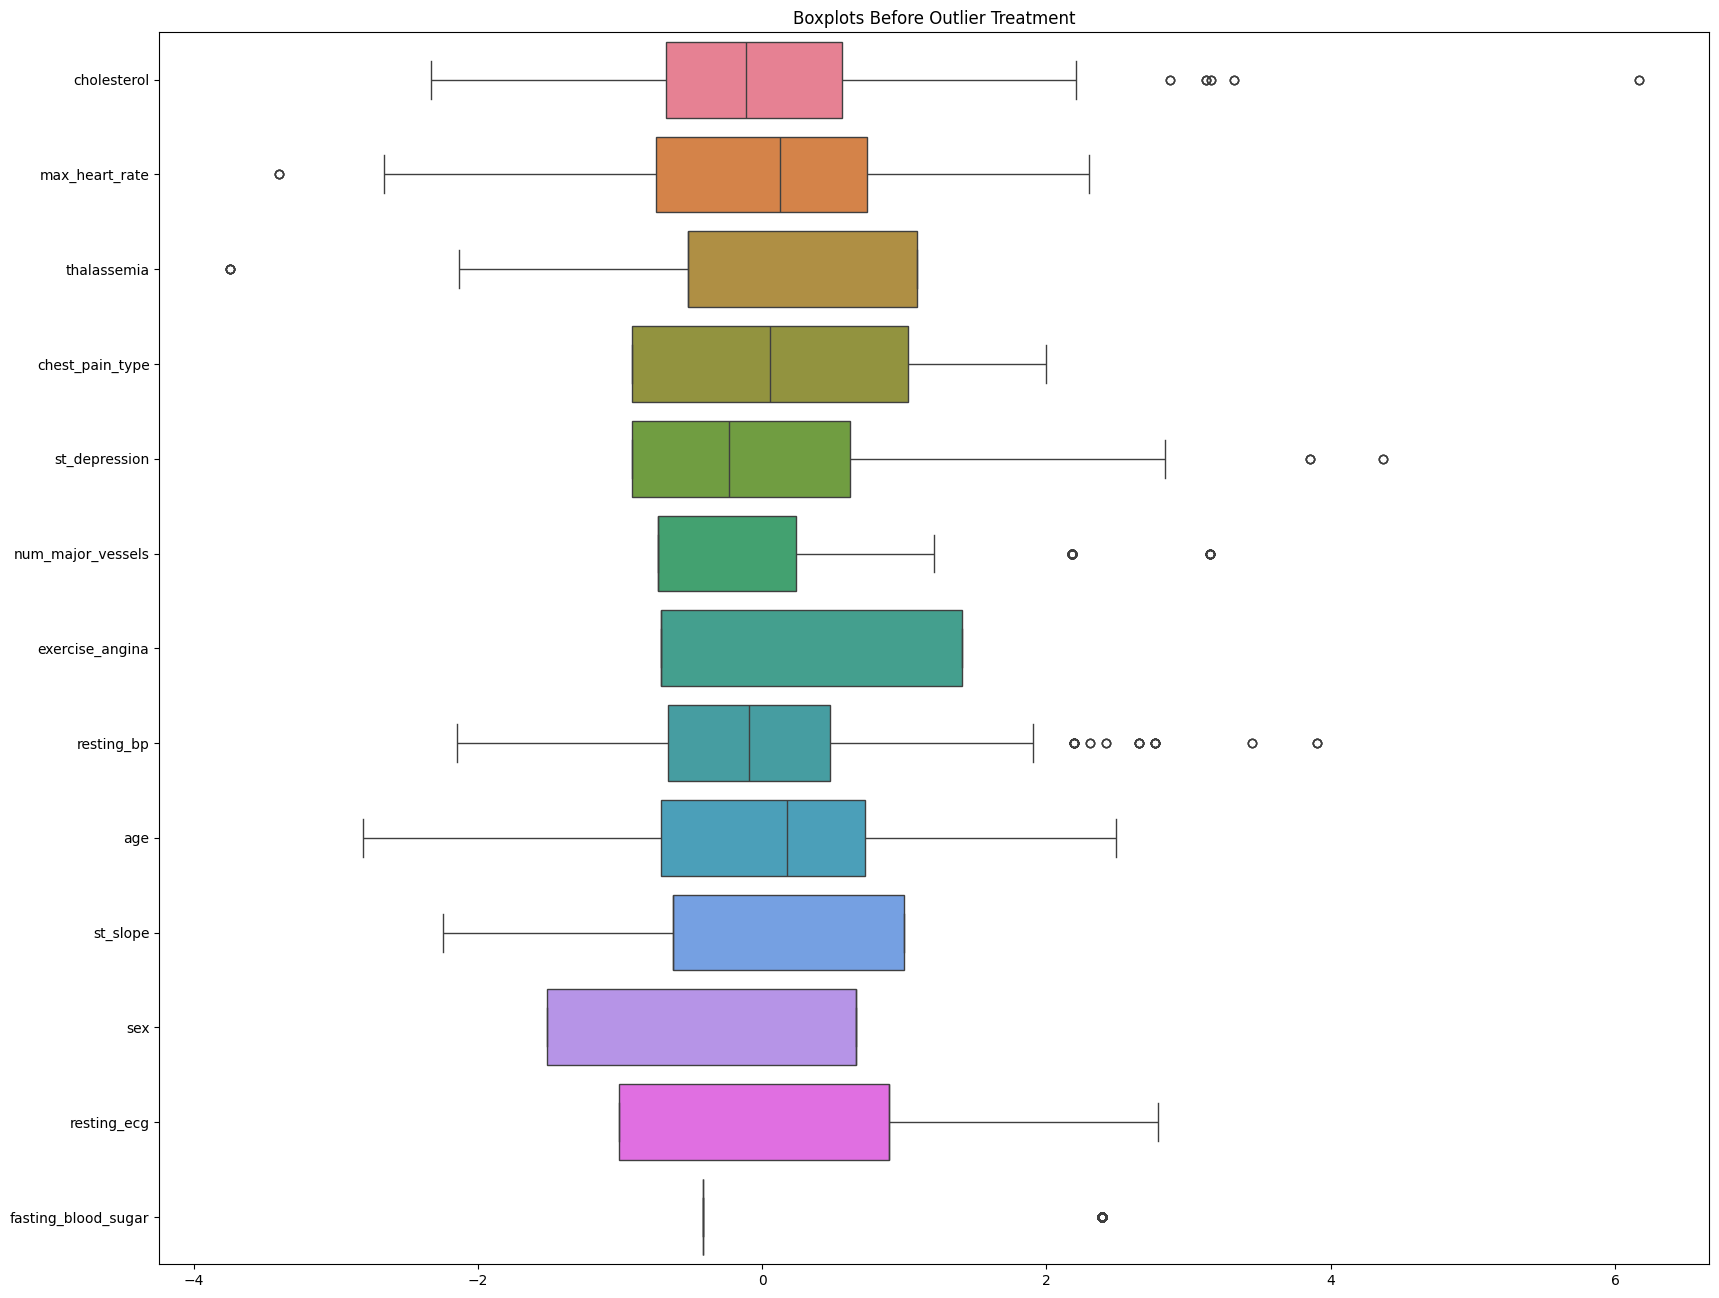

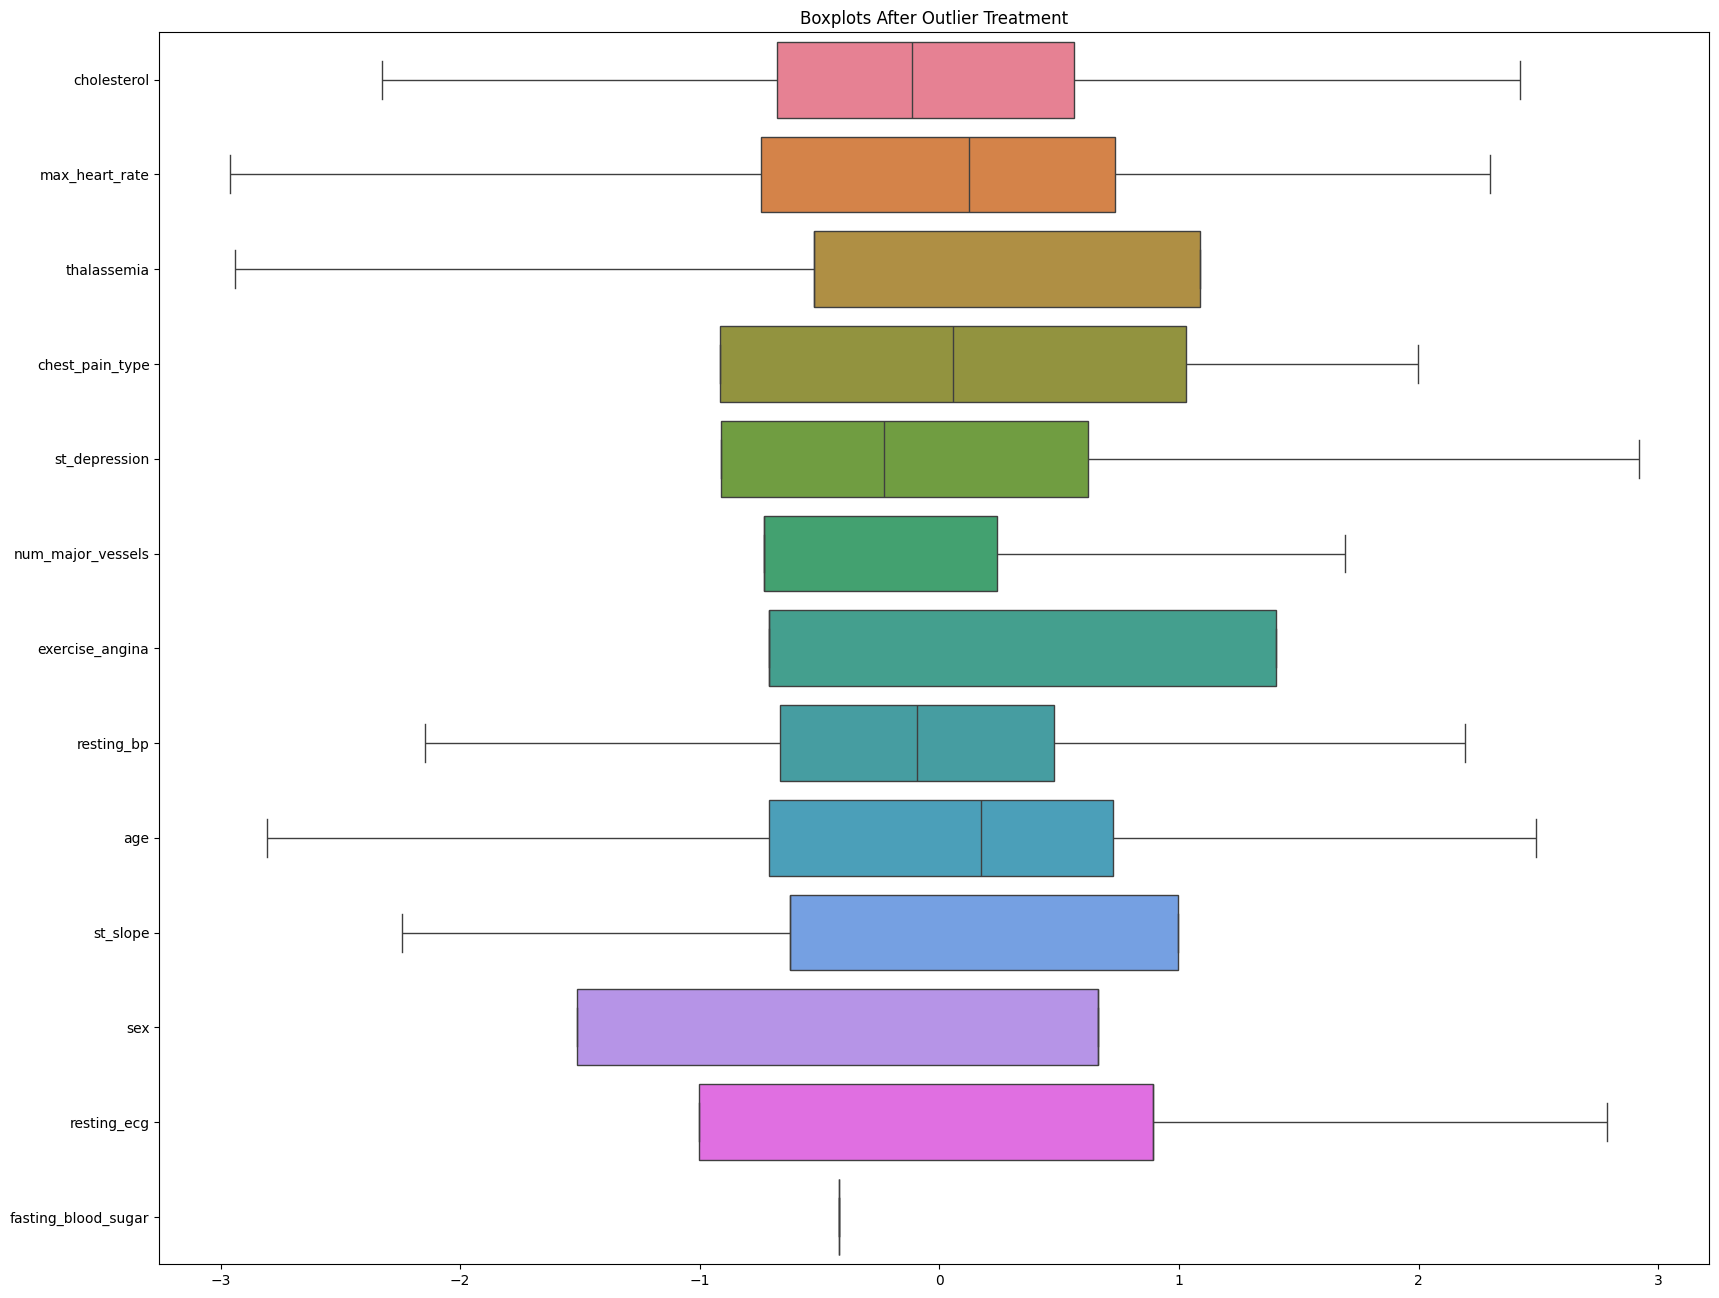

In [ ]:
# Outlier Removal

num_cols_all = df.select_dtypes(include=np.number).columns.tolist()
num_cols_all.remove('heart_disease')

# Boxplot before
plt.figure(figsize=(20,16))
sns.boxplot(data=df[num_cols_all], orient='h')
plt.title("Boxplots Before Outlier Treatment")
plt.show()

# IQR capping
Q1 = df[num_cols_all].quantile(0.25)
Q3 = df[num_cols_all].quantile(0.75)
IQR = Q3 - Q1

df_capped = df.copy()
for col in num_cols_all:
    low, high = Q1[col] - 1.5*IQR[col], Q3[col] + 1.5*IQR[col]
    df_capped[col] = df_capped[col].clip(lower=low, upper=high)

# Boxplot after
plt.figure(figsize=(20,16))
sns.boxplot(data=df_capped[num_cols_all], orient='h')
plt.title("Boxplots After Outlier Treatment")
plt.show()

In [ ]:
# Define save folder
PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"
SAVE_FOLDER = os.path.join(PROJECT_PATH, "results/eda_visualizations/outlier_removal")
os.makedirs(SAVE_FOLDER, exist_ok=True)

def save_plot(filename):
    """Save current matplotlib figure to SAVE_FOLDER"""
    plot_path = os.path.join(SAVE_FOLDER, filename)
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Plot saved: {plot_path}")

# Save boxplot BEFORE outlier treatment
plt.figure(figsize=(10,6))
sns.boxplot(data=df[num_cols_all], orient='h')
plt.title("Boxplots Before Outlier Treatment")
save_plot("boxplot_before_outlier_treatment.png")
plt.close()

# Save boxplot AFTER outlier treatment
plt.figure(figsize=(10,6))
sns.boxplot(data=df_capped[num_cols_all], orient='h')
plt.title("Boxplots After Outlier Treatment")
save_plot("boxplot_after_outlier_treatment.png")
plt.close()

Plot saved: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/eda_visualizations/outlier_removal/boxplot_before_outlier_treatment.png
Plot saved: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/eda_visualizations/outlier_removal/boxplot_after_outlier_treatment.png


In [ ]:
# Updates .csv file save
df_final_4 = df_capped.copy()

print("Final dataset ready for ML:", df_final_4.shape)

PROC_PATH = os.path.join(PROJECT_PATH, "data/processed/IT24102775_ outlier_removal(4th).csv")
df_final_4.to_csv(PROC_PATH, index=False)
print("Saved outlier-treated dataset to:", PROC_PATH)

Final dataset ready for ML: (1025, 14)
Saved outlier-treated dataset to: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/data/processed/IT24102775_ outlier_removal(4th).csv


In [ ]:
# Preprocessing Technique 5- Data Transformation (IT24102697 Jayawardhana D.D.S.)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from google.colab import drive

drive.mount('/content/drive')

PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"
RAW_PATH = f"{PROJECT_PATH}/data/processed/IT24102775_ outlier_removal(4th).csv"

# Load dataset
df = pd.read_csv(RAW_PATH)
print("Dataset loaded:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded: (1025, 14)


,cholesterol,max_heart_rate,thalassemia,chest_pain_type,st_depression,num_major_vessels,exercise_angina,resting_bp,age,st_slope,sex,resting_ecg,fasting_blood_sugar,heart_disease
0,-0.659332,0.821321,1.089852,-0.915755,-0.060888,1.209221,-0.712287,-0.377636,-0.268437,0.995433,0.661504,0.891255,-0.418878,0
1,-0.833861,0.255968,1.089852,-0.915755,1.727137,-0.731971,1.403928,0.479107,-0.158157,-2.243675,0.661504,-1.004049,-0.418878,0
2,-1.396233,-1.048692,1.089852,-0.915755,1.301417,-0.731971,1.403928,0.764688,1.716595,-2.243675,0.661504,0.891255,-0.418878,0
3,-0.833861,0.516900,1.089852,-0.915755,-0.912329,0.238625,-0.712287,0.936037,0.724079,0.995433,0.661504,0.891255,-0.418878,0
4,0.930822,-1.874977,-0.522122,-0.915755,0.705408,1.694519,-0.712287,0.364875,0.834359,-0.624121,-1.511706,0.891255,-0.418878,0


In [ ]:
# Data Transformation

from scipy.stats import skew

num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('heart_disease')

# Filter numeric columns with more than 1 unique value
num_cols_filtered = [c for c in num_cols if df[c].nunique() > 1]

# Skewness check
skew_vals = df[num_cols_filtered].apply(lambda x: skew(x))
print("Skewness values:\n", skew_vals)

# Apply log1p
df_trans = df.copy()
for col in num_cols_filtered:
    if abs(skew_vals[col]) > 0.75 and (df_trans[col] >= 0).all():
        df_trans[col] = np.log1p(df_trans[col])
        print(f"Applied log1p to {col}")

Skewness values:
 cholesterol          0.343310
max_heart_rate      -0.474164
thalassemia         -0.374586
chest_pain_type      0.528680
st_depression        1.017811
num_major_vessels    0.863461
exercise_angina      0.691641
resting_bp           0.401695
age                 -0.248502
st_slope            -0.478433
sex                 -0.850202
resting_ecg          0.180176
dtype: float64


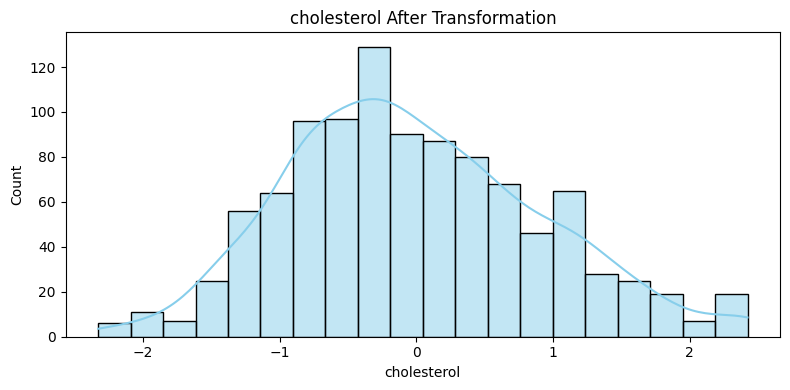

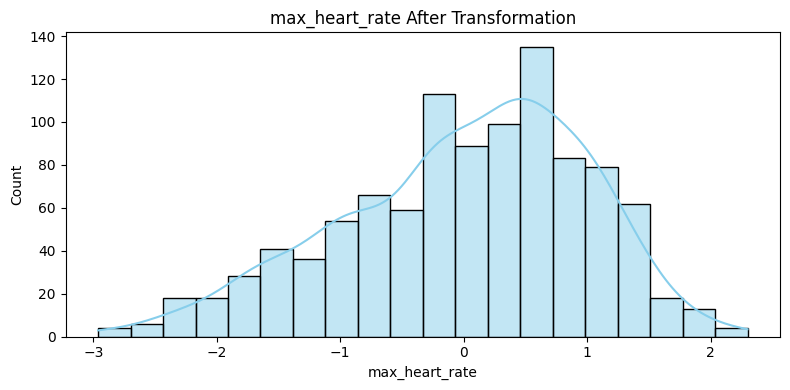

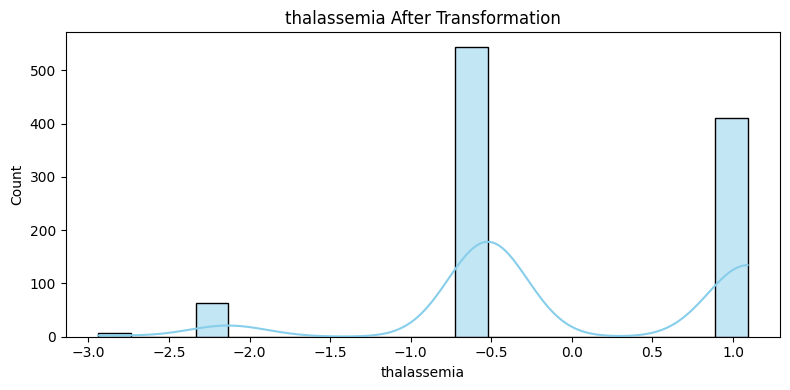

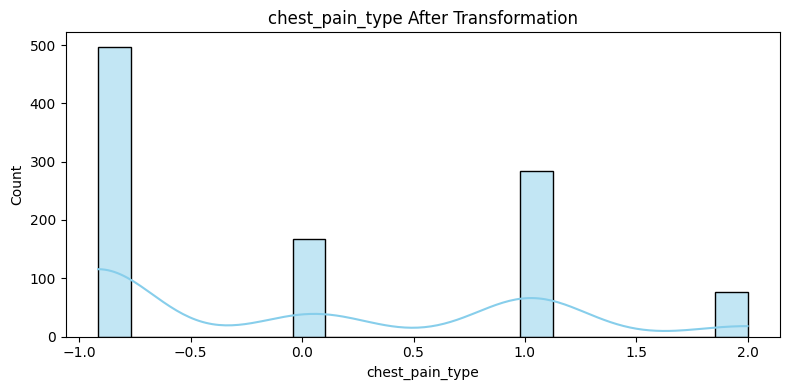

In [ ]:
# Visualization
for col in num_cols[:4]:  # show first 4 to keep plots manageable
    fig, ax = plt.subplots(figsize=(8, 4))

    # After transform
    sns.histplot(df_trans[col], bins=20, kde=True, color="skyblue", ax=ax)
    ax.set_title(f"{col} After Transformation")

    plt.tight_layout()
    plt.show()

In [ ]:
# Define save folder
SAVE_FOLDER = os.path.join(PROJECT_PATH, "results/eda_visualizations/data_transformation")
os.makedirs(SAVE_FOLDER, exist_ok=True)

#  Save plots
plot_path = os.path.join(SAVE_FOLDER, f"{col}_log_transform.png")
fig.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Saved plot: {plot_path}")
plt.close(fig)

Saved plot: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/eda_visualizations/data_transformation/chest_pain_type_log_transform.png


In [ ]:
# Save updated dataset
PROC_PATH = os.path.join(PROJECT_PATH, "data/processed/IT24102697_transformed(5th).csv")
df_trans.to_csv(PROC_PATH, index=False)
print("Transformed dataset saved at:", PROC_PATH)

Transformed dataset saved at: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/data/processed/IT24102697_transformed(5th).csv


In [ ]:
# Preprocessing Technique 6- Correlation Thresholding (IT24102706 Priyadarshani G.P.S.D.)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from google.colab import drive

drive.mount('/content/drive')

PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"
RAW_PATH = f"{PROJECT_PATH}/data/processed/IT24102697_transformed(5th).csv"

# Load dataset
df = pd.read_csv(RAW_PATH)
print("Dataset loaded:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded: (1025, 14)


,cholesterol,max_heart_rate,thalassemia,chest_pain_type,st_depression,num_major_vessels,exercise_angina,resting_bp,age,st_slope,sex,resting_ecg,fasting_blood_sugar,heart_disease
0,-0.659332,0.821321,1.089852,-0.915755,-0.060888,1.209221,-0.712287,-0.377636,-0.268437,0.995433,0.661504,0.891255,-0.418878,0
1,-0.833861,0.255968,1.089852,-0.915755,1.727137,-0.731971,1.403928,0.479107,-0.158157,-2.243675,0.661504,-1.004049,-0.418878,0
2,-1.396233,-1.048692,1.089852,-0.915755,1.301417,-0.731971,1.403928,0.764688,1.716595,-2.243675,0.661504,0.891255,-0.418878,0
3,-0.833861,0.516900,1.089852,-0.915755,-0.912329,0.238625,-0.712287,0.936037,0.724079,0.995433,0.661504,0.891255,-0.418878,0
4,0.930822,-1.874977,-0.522122,-0.915755,0.705408,1.694519,-0.712287,0.364875,0.834359,-0.624121,-1.511706,0.891255,-0.418878,0


Feature correlation with heart disease:
 heart_disease          1.000000
chest_pain_type        0.434854
max_heart_rate         0.423445
st_slope               0.345512
resting_ecg            0.134468
cholesterol           -0.118254
resting_bp            -0.132301
age                   -0.229324
sex                   -0.279501
thalassemia           -0.345187
num_major_vessels     -0.432324
exercise_angina       -0.438029
st_depression         -0.442847
fasting_blood_sugar         NaN
Name: heart_disease, dtype: float64
Most predictive features: ['chest_pain_type', 'max_heart_rate', 'st_slope', 'resting_ecg', 'resting_bp', 'age', 'sex', 'thalassemia', 'num_major_vessels', 'exercise_angina', 'st_depression']
Final dataset shape: (1025, 12)


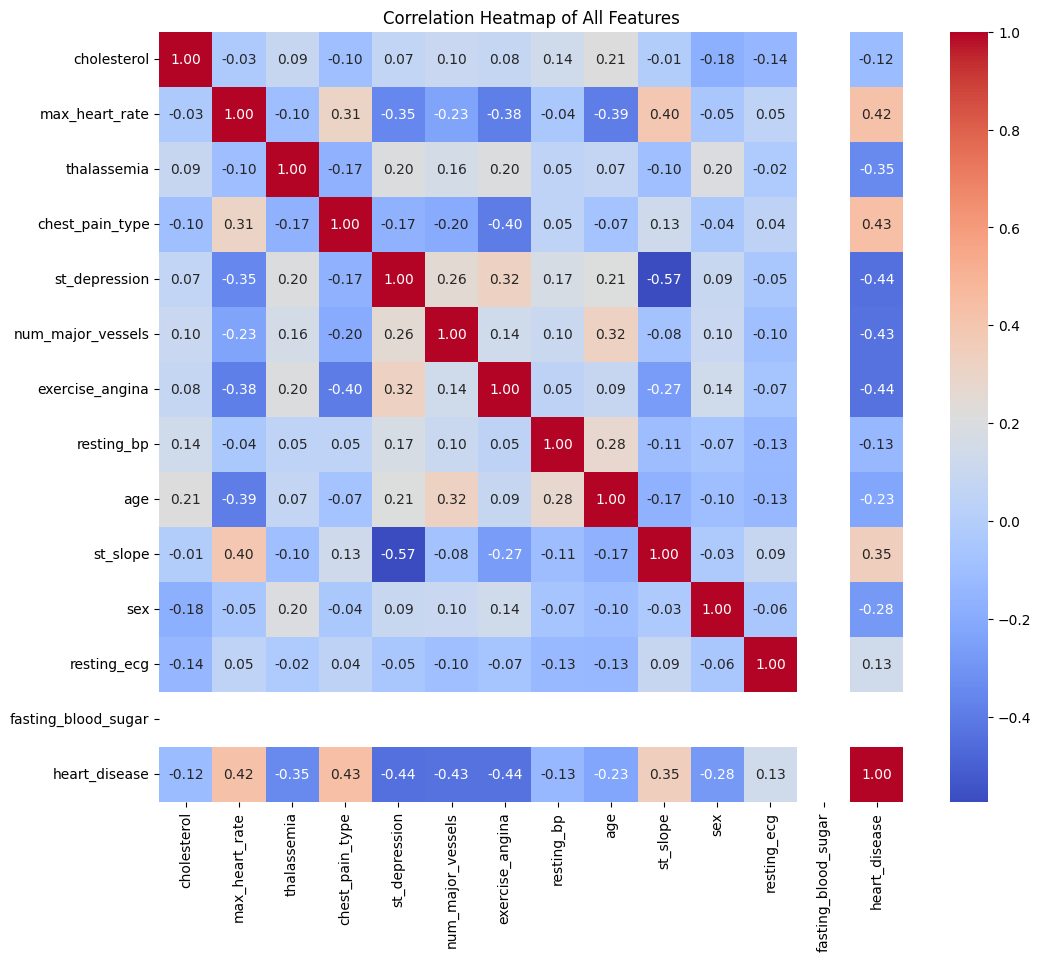

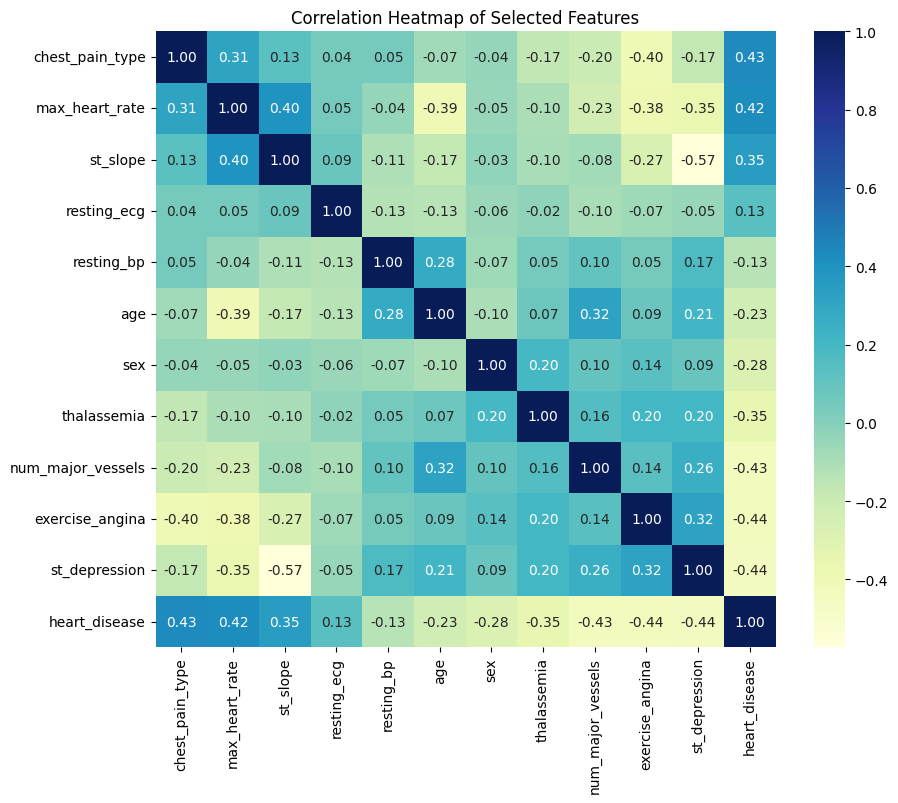

In [ ]:
# Correlation thresholding

# Compute correlation of features with target
target_corr = df.corr()['heart_disease'].sort_values(ascending=False)
print("Feature correlation with heart disease:\n", target_corr)

# Keep only features with correlation > 0.12
important_features = target_corr[abs(target_corr) > 0.12].index.tolist()
important_features.remove('heart_disease')  # remove target itself
print("Most predictive features:", important_features)

# Final dataset with selected features + target
df_final_6 = df[important_features + ['heart_disease']].copy()
print("Final dataset shape:", df_final_6.shape)

# Correlation heatmap for all features
fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Correlation Heatmap of All Features")
plt.show()

# Correlation heatmap for final selected features
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(df_final_6.corr(), annot=True, cmap="YlGnBu", fmt=".2f", ax=ax)
ax.set_title("Correlation Heatmap of Selected Features")
plt.show()

In [ ]:
# Define save folder
SAVE_FOLDER = os.path.join(PROJECT_PATH, "results/eda_visualizations/Correlation_thresholding")
os.makedirs(SAVE_FOLDER, exist_ok=True)

#  Save plots
plot_path = os.path.join(SAVE_FOLDER, "correlation_heatmap_all_features.png")
fig.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.close(fig)
print(f"Saved plot: {plot_path}")

plot_path = os.path.join(SAVE_FOLDER, "correlation_heatmap_selected_features.png")
fig.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.close(fig)
print(f"Saved plot: {plot_path}")

Saved plot: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/eda_visualizations/Correlation_thresholding/correlation_heatmap_all_features.png
Saved plot: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/eda_visualizations/Correlation_thresholding/correlation_heatmap_selected_features.png


In [ ]:
# Save updated dataset
PROC_PATH = os.path.join(PROJECT_PATH, "data/processed/IT24102706_correlation_thresholding(6th).csv")
os.makedirs(os.path.dirname(PROC_PATH), exist_ok=True)
df_final_6.to_csv(PROC_PATH, index=False)
print("Saved final selected dataset to:", PROC_PATH)

Saved final selected dataset to: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/data/processed/IT24102706_correlation_thresholding(6th).csv


In [ ]:
# -----------Final Preprocess Dataset Save-------------

In [ ]:
# Define project paths
PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"

# Previous processed dataset path (already saved earlier)
PREV_DATASET_PATH = os.path.join(PROJECT_PATH, "data/processed/IT24102706_correlation_thresholding(6th).csv")

# New final output folder
OUTPUT_FOLDER = os.path.join(PROJECT_PATH, "results/output")
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Load dataset
df_prev = pd.read_csv(PREV_DATASET_PATH)

# Define new order
new_order = [
    'age', 'sex',                          # Demographic
    'resting_bp', 'max_heart_rate',        # Vital signs
    'chest_pain_type', 'resting_ecg',      # Symptoms
    'st_depression', 'st_slope',           # ECG-related
    'exercise_angina',                     # Exercise-induced
    'num_major_vessels', 'thalassemia',    # Diagnostic
    'heart_disease'                        # Target
]

# Reorder dataset
df_final = df_prev[new_order]

df_final.head()

,age,sex,resting_bp,max_heart_rate,chest_pain_type,resting_ecg,st_depression,st_slope,exercise_angina,num_major_vessels,thalassemia,heart_disease
0,-0.268437,0.661504,-0.377636,0.821321,-0.915755,0.891255,-0.060888,0.995433,-0.712287,1.209221,1.089852,0
1,-0.158157,0.661504,0.479107,0.255968,-0.915755,-1.004049,1.727137,-2.243675,1.403928,-0.731971,1.089852,0
2,1.716595,0.661504,0.764688,-1.048692,-0.915755,0.891255,1.301417,-2.243675,1.403928,-0.731971,1.089852,0
3,0.724079,0.661504,0.936037,0.516900,-0.915755,0.891255,-0.912329,0.995433,-0.712287,0.238625,1.089852,0
4,0.834359,-1.511706,0.364875,-1.874977,-0.915755,0.891255,0.705408,-0.624121,-0.712287,1.694519,-0.522122,0


In [ ]:
# Save final dataset
FINAL_DATA_PATH = os.path.join(OUTPUT_FOLDER, "heart_dataset_final.csv")
df_final.to_csv(FINAL_DATA_PATH, index=False)

print("Final dataset saved successfully!")
print("Saved at:", FINAL_DATA_PATH)
print("Shape of final dataset:", df_final.shape)

Final dataset saved successfully!
Saved at: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/output/heart_dataset_final.csv
Shape of final dataset: (1025, 12)
